# Week 6 - Assignment Data Sets
## Cameron Gray

In this assignment we are analyzing the David Southern Club Women. How the clubs and the women are connected to themselves and each other.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
from networkx.algorithms import bipartite as bi

This data set is available within `networkx` and it is set up as a bipartite graph by default. You simply call it following the documentation on the [`nextworkx` website](https://networkx.org/documentation/stable/auto_examples/algorithms/plot_davis_club.html).

In [2]:
G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

We can see a list of all the nodes that represent the women here:

In [3]:
women

['Evelyn Jefferson',
 'Laura Mandeville',
 'Theresa Anderson',
 'Brenda Rogers',
 'Charlotte McDowd',
 'Frances Anderson',
 'Eleanor Nye',
 'Pearl Oglethorpe',
 'Ruth DeSand',
 'Verne Sanderson',
 'Myra Liddel',
 'Katherina Rogers',
 'Sylvia Avondale',
 'Nora Fayette',
 'Helen Lloyd',
 'Dorothy Murchison',
 'Olivia Carleton',
 'Flora Price']

We can see a list of all the nodes that represent the clubs here:

In [4]:
clubs

['E1',
 'E2',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'E8',
 'E9',
 'E10',
 'E11',
 'E12',
 'E13',
 'E14']

This is just a simple visualization of the graph that is displayed on the site. It unfortunately is not the best way to look at this data because it is hard to differentiate the women from the clubs and see how they all relate.

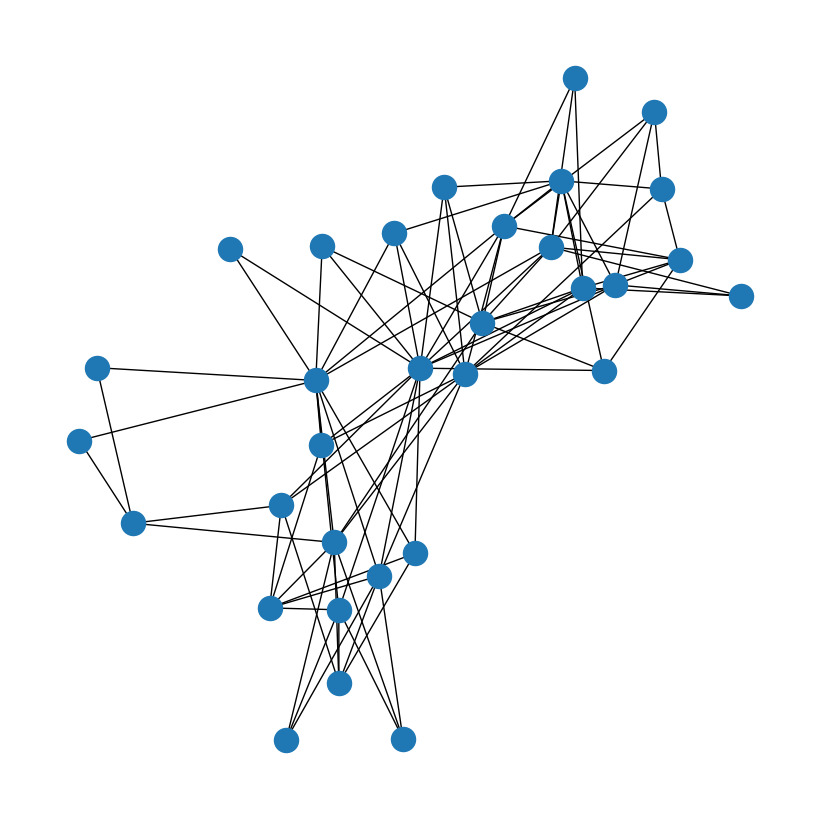

In [5]:
plt.figure(figsize=(8, 8))
nx.draw(G)

By simply adding color and labels we can easily see that there is a lot more going on with this graph than the earlier figure would imply. The blue nodes are the women and the red nodes are the clubs. But even with this visualization it is different to get a full picture of what is going on here.

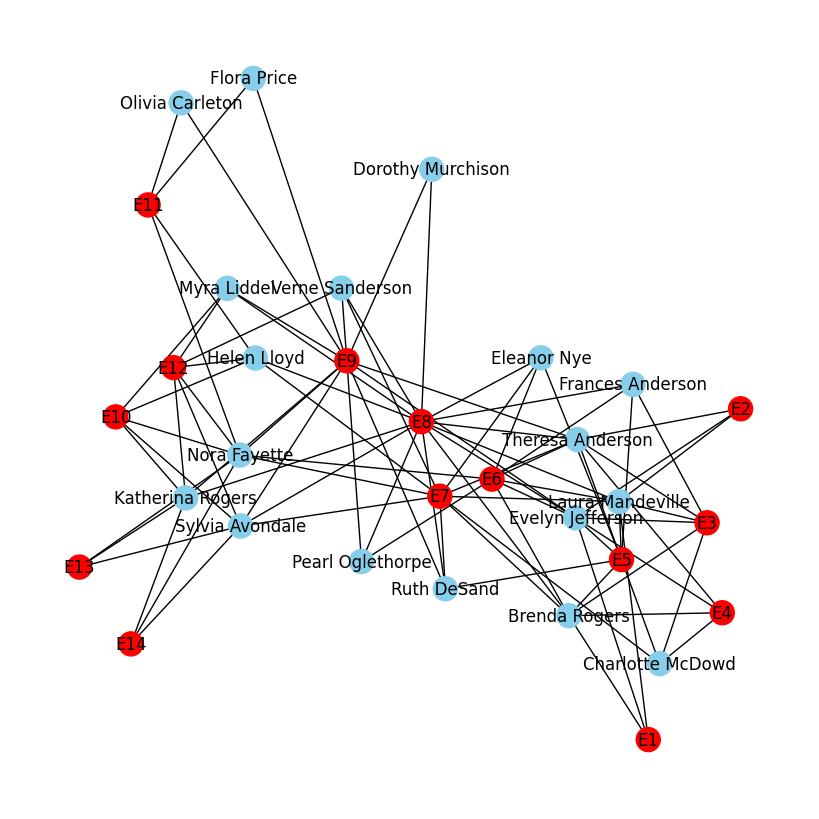

In [6]:
color = ['skyblue']*18 + ['red']*14
plt.figure(figsize=(8, 8))
nx.draw(G, with_labels = True, node_color=color)

To see things a bit more clearly we can create a circular graph which gets quite busy towards the middle but it is easier to to count the edges for each node.

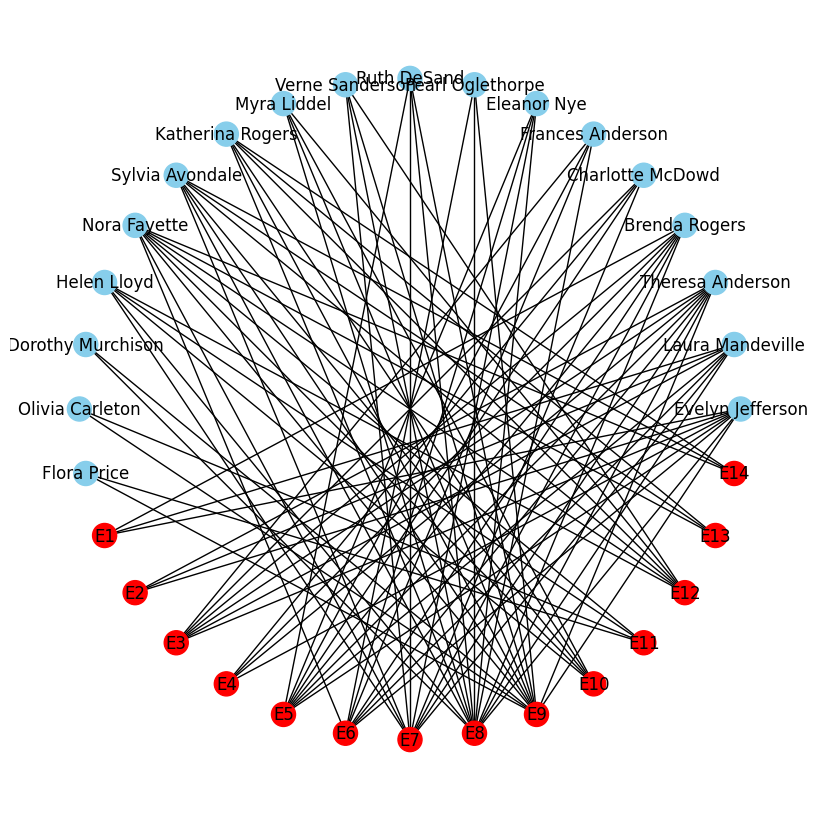

In [7]:
color = ['skyblue']*18 + ['red']*14
plt.figure(figsize=(8, 8))
nx.draw_circular(G, with_labels = True, node_color=color)

The arguably best way to visualize bipartite graph is to segment them into two distinct sides for the two subsets. This allows for the easiest reading of this type of graph.

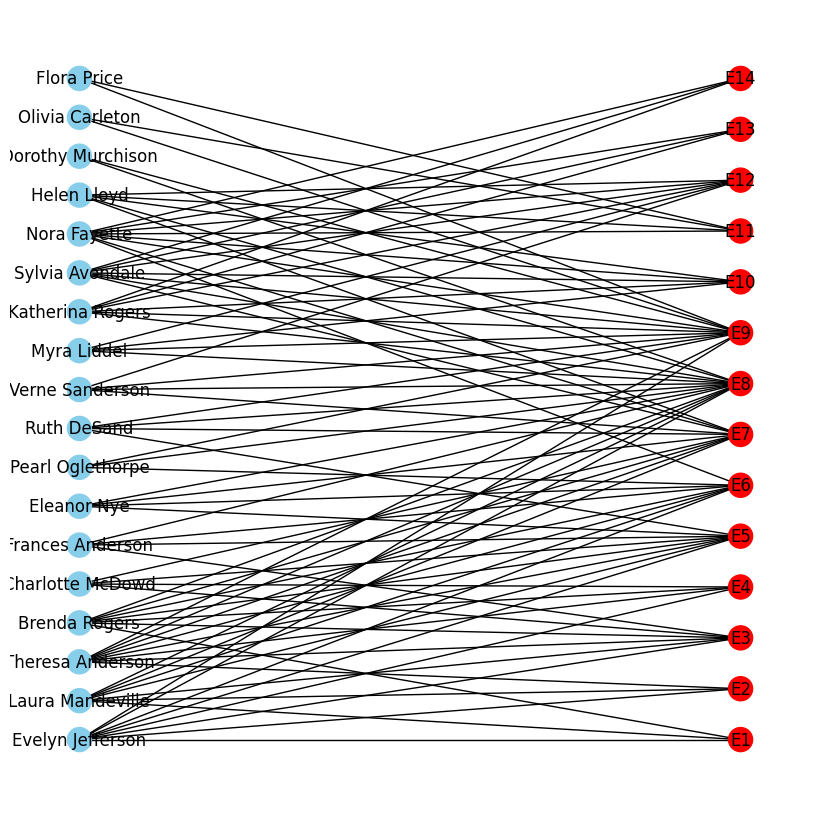

In [8]:
pos = nx.bipartite_layout(G)
plt.figure(figsize=(8,8))
nx.draw(G, pos, with_labels = True, node_color=color)

Now that we have a visualization of the graph we can easily see the connections between all the nodes we can start to measure centrality metrics to see how connected the network is and how that relates to those involved. By assigning these metrics to both the women and the clubs we can get the measures for both sets of nodes and gives insight that would otherwise be shrouded by using the clubs as edges.

In [9]:
dc = pd.DataFrame.from_dict(bi.degree_centrality(G, women), 
                            orient='index', columns = ['degree'])
cc = pd.DataFrame.from_dict(bi.closeness_centrality(G, women), 
                            orient='index', columns = ['closeness'])
bc = pd.DataFrame.from_dict(bi.betweenness_centrality(G, women), 
                            orient='index', columns = ['betweenness'])
cluster = pd.DataFrame.from_dict(bi.clustering(G), 
                            orient='index', columns = ['clustering'])

After compiling all the centrality metrics into a single dataframe we can put together some metrics to see how individuals and clubs stack up against the respective sets.

In [10]:
data = dc.join(bc).join(cc).join(cluster).reset_index()
data.insert(loc = 0, column = 'type', value=['women']*18 + ['clubs']*14)
data.set_index(['type', 'index'], inplace=True)
data.sort_index(level=[0,1], ascending=[False,True], inplace=True)
data

degree  betweenness  closeness  clustering
type  index                                                          
women Brenda Rogers      0.500000     0.049487   0.727273    0.364912
      Charlotte McDowd   0.285714     0.010596   0.600000    0.294412
      Dorothy Murchison  0.142857     0.001954   0.648649    0.305010
      Eleanor Nye        0.285714     0.009444   0.666667    0.360317
      Evelyn Jefferson   0.571429     0.096585   0.800000    0.317943
      Flora Price        0.142857     0.005055   0.585366    0.257507
      Frances Anderson   0.285714     0.010714   0.666667    0.314817
      Helen Lloyd        0.357143     0.042388   0.727273    0.261699
      Katherina Rogers   0.428571     0.047363   0.727273    0.297495
      Laura Mandeville   0.500000     0.051358   0.727273    0.351817
      Myra Liddel        0.285714     0.016344   0.685714    0.324405
      Nora Fayette       0.571429     0.113461   0.800000    0.260577
      Olivia Carleton    0.142857     0.005055   0.585366    0.257507
      Pearl Oglethorpe   0.214286     0.006800   0.666667    0.332341
      Ruth DeSand        0.285714     0.016783   0.705882    0.364356
      Sylvia Avondale    0.500000     0.071709   0.774194    0.322752
      Theresa Anderson   0.571429     0.087595   0.800000    0.371819
      Verne Sanderson    0.285714     0.015738   0.705882    0.348833
clubs E1                 0.166667     0.002154   0.523810    0.327192
      E10                0.277778     0.011442   0.550000    0.403342
      E11                0.222222     0.019665   0.536585    0.177027
      E12                0.333333     0.018094   0.564103    0.401442
      E13                0.166667     0.002241   0.523810    0.366477
      E14                0.166667     0.002241   0.523810    0.366477
      E2                 0.166667     0.002089   0.523810    0.337494
      E3                 0.333333     0.018224   0.564103    0.470486
      E4                 0.222222     0.007702   0.536585    0.364448
      E5                 0.444444     0.037694   0.594595    0.467892
      E6                 0.444444     0.065016   0.687500    0.291641
      E7                 0.555556     0.129502   0.733333    0.289390
      E8                 0.777778     0.243819   0.846154    0.296165
      E9                 0.666667     0.225514   0.785714    0.243555

Summary statistics:

In [11]:
data.groupby('type').agg(['max','min','mean','median']).T

type                   clubs     women
degree      max     0.777778  0.571429
            min     0.166667  0.142857
            mean    0.353175  0.353175
            median  0.305556  0.285714
betweenness max     0.243819  0.113461
            min     0.002089  0.001954
            mean    0.056100  0.036579
            median  0.018159  0.016564
closeness   max     0.846154  0.800000
            min     0.523810  0.585366
            mean    0.606708  0.700008
            median  0.557051  0.705882
clustering  max     0.470486  0.371819
            min     0.177027  0.257507
            mean    0.343073  0.317140
            median  0.350971  0.320348

### Top 5s

Top 5 Women Ranked by Degree Centrality:

In [12]:
data.loc['women'].sort_values(by='degree', 
                              ascending = False).head(5)['degree']

index
Nora Fayette        0.571429
Theresa Anderson    0.571429
Evelyn Jefferson    0.571429
Brenda Rogers       0.500000
Sylvia Avondale     0.500000
Name: degree, dtype: float64

Top 5 Women Ranked by Closeness Centrality:

In [13]:
data.loc['women'].sort_values(by='closeness', 
                              ascending = False).head(5)['closeness']

index
Theresa Anderson    0.800000
Evelyn Jefferson    0.800000
Nora Fayette        0.800000
Sylvia Avondale     0.774194
Brenda Rogers       0.727273
Name: closeness, dtype: float64

Top 5 Women Ranked by Betweenness Centrality:

In [14]:
data.loc['women'].sort_values(by='betweenness', 
                              ascending = False).head(5)['betweenness']

index
Nora Fayette        0.113461
Evelyn Jefferson    0.096585
Theresa Anderson    0.087595
Sylvia Avondale     0.071709
Laura Mandeville    0.051358
Name: betweenness, dtype: float64

Top 5 Clubs Ranked by Degree Centrality:

In [15]:
data.loc['clubs'].sort_values(by='degree', 
                              ascending = False).head(5)['degree']

index
E8    0.777778
E9    0.666667
E7    0.555556
E5    0.444444
E6    0.444444
Name: degree, dtype: float64

Top 5 Clubs Ranked by Closeness Centrality:

In [16]:
data.loc['clubs'].sort_values(by='closeness', 
                              ascending = False).head(5)['closeness']

index
E8    0.846154
E9    0.785714
E7    0.733333
E6    0.687500
E5    0.594595
Name: closeness, dtype: float64

Top 5 Clubs Ranked by Betweenness Centrality:

In [17]:
data.loc['clubs'].sort_values(by='betweenness', 
                              ascending = False).head(5)['betweenness']

index
E8    0.243819
E9    0.225514
E7    0.129502
E6    0.065016
E5    0.037694
Name: betweenness, dtype: float64

### Bottom 5s

Bottom 5 Women Ranked by Degree Centrality:

In [18]:
data.loc['women'].sort_values(by='degree', 
                              ascending = True).head(5)['degree']

index
Dorothy Murchison    0.142857
Flora Price          0.142857
Olivia Carleton      0.142857
Pearl Oglethorpe     0.214286
Verne Sanderson      0.285714
Name: degree, dtype: float64

Bottom 5 Women Ranked by Closeness Centrality:

In [19]:
data.loc['women'].sort_values(by='closeness', 
                              ascending = True).head(5)['closeness']

index
Flora Price          0.585366
Olivia Carleton      0.585366
Charlotte McDowd     0.600000
Dorothy Murchison    0.648649
Eleanor Nye          0.666667
Name: closeness, dtype: float64

Bottom 5 Women Ranked by Betweenness Centrality:

In [20]:
data.loc['women'].sort_values(by='betweenness', 
                              ascending = True).head(5)['betweenness']

index
Dorothy Murchison    0.001954
Flora Price          0.005055
Olivia Carleton      0.005055
Pearl Oglethorpe     0.006800
Eleanor Nye          0.009444
Name: betweenness, dtype: float64

Bottom 5 Clubs Ranked by Degree Centrality:

In [21]:
data.loc['clubs'].sort_values(by='degree', 
                              ascending = True).head(5)['degree']

index
E1     0.166667
E13    0.166667
E14    0.166667
E2     0.166667
E11    0.222222
Name: degree, dtype: float64

Bottom 5 Clubs Ranked by Closeness Centrality:

In [22]:
data.loc['clubs'].sort_values(by='closeness', 
                              ascending = True).head(5)['closeness']

index
E1     0.523810
E13    0.523810
E14    0.523810
E2     0.523810
E11    0.536585
Name: closeness, dtype: float64

Bottom 5 Clubs Ranked by Betweenness Centrality:

In [23]:
data.loc['clubs'].sort_values(by='betweenness', 
                              ascending = True).head(5)['betweenness']

index
E2     0.002089
E1     0.002154
E13    0.002241
E14    0.002241
E4     0.007702
Name: betweenness, dtype: float64

As far as the women go we can very clearly see that `Nora Fayette` is definitely the most central woman in this network. She has the highest value for degree, closeness and betweenness centrality meaning that she has attended the most clubs, she is the most well connected in the network (there aren't many steps to get from her to any other node) and she tends to be in the shortest path connecting all the other nodes in the network, respectively. Two other women `Theresa Anderson` and `Evelyn Jefferson` both have the same scores in degree and closeness but slightly lower scores in betweenness. Having all of that information these three women definitely are so central because they attended half of the overall events giving them very important placement in the network allowing for many paths to travel "through" them. 

On the other hand, for the clubs it is very clear to see the ranking in the top 5 events. From `E8`, `E9`, `E7`, `E6`, and `E5`, in that order, we have a clear ranking for which ones are the most influential on the network. It follows that the ones with the highest degree give the most connectedness for closeness and betweenness. Since the events have more women attending them it gives those women attending other events a chance to create paths to connect to other women and other clubs. We can also see that the clubs tend to have higher centrality than the women because there tend to be more women attending the clubs than there are clubs that the women attend which gives way to this trend. 

Overall, there isn't too much unexpected about this network. The highly attend events and the women who attended the most events have the most influence in the network, whereas the lowest attended events and the women who attened the least events have the least influence. Again none of this is surprising, I think the real merit of investigating this network comes from being able to run analytics on what would typically be considered an edge in a network but instead being treated as a node gives an extra layer to the network.